# Example: Space Dataset (NASA Exoplanet Archive)

Live pull of confirmed exoplanets from NASA's Exoplanet Archive TAP API — no API key needed.

Columns: planet name, host star, orbital period (days), planet radius (Earth radii), planet mass (Earth masses), stellar effective temperature (K).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Pulls live data directly from NASA's Exoplanet Archive TAP service.
# If offline, falls back to the cached CSV saved alongside this notebook.
TAP_URL = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query="
    "select+pl_name,hostname,pl_orbper,pl_rade,pl_bmasse,st_teff+"
    "from+ps+where+default_flag=1&format=csv"
)

try:
    exoplanets_df = pd.read_csv(TAP_URL)
except Exception:
    exoplanets_df = pd.read_csv("exoplanets_sample.csv")

exoplanets_df = exoplanets_df.rename(columns={
    "pl_name": "planet_name",
    "hostname": "host_star",
    "pl_orbper": "orbital_period_days",
    "pl_rade": "radius_earth_radii",
    "pl_bmasse": "mass_earth_masses",
    "st_teff": "star_temp_kelvin"
})

print(f"{len(exoplanets_df):,} confirmed exoplanets loaded")
exoplanets_df.head()

6,360 confirmed exoplanets loaded


,planet_name,host_star,orbital_period_days,radius_earth_radii,mass_earth_masses,star_temp_kelvin
0,Kepler-1513 b,Kepler-1513,160.884200,8.594000,48.309918,5491.0
1,TOI-4914 b,TOI-4914,10.600570,12.870000,227.000000,5805.0
2,TOI-237 c,TOI-237,1.744861,1.206000,NaN,3226.0
3,TOI-1898 b,TOI-1898,45.522340,9.395532,129.000000,6241.0
4,HD 330075 b,HD 330075,3.387730,NaN,152.558400,5000.0


## Tabular data format (styled preview)

In [2]:
styled_exoplanets_table = (
    exoplanets_df
    .dropna(subset=["radius_earth_radii", "mass_earth_masses", "star_temp_kelvin"])
    .sort_values("mass_earth_masses")
    .head(8)
    .style
    .format({
        "orbital_period_days": "{:.1f}",
        "radius_earth_radii": "{:.2f}",
        "mass_earth_masses": "{:.2f}",
        "star_temp_kelvin": "{:.0f}"
    })
    .set_caption("Sample: Lowest-Mass Confirmed Exoplanets")
    .set_table_styles([
        {"selector": "caption", "props": [
            ("caption-side", "top"), ("font-size", "24px"),
            ("font-weight", "bold"), ("text-align", "left"), ("padding", "10px")
        ]},
        {"selector": "th", "props": [
            ("font-size", "16px"), ("background-color", "#1f4e79"),
            ("color", "white"), ("padding", "8px"), ("text-align", "left")
        ]},
        {"selector": "td", "props": [
            ("font-size", "16px"), ("padding", "8px"), ("text-align", "left")
        ]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]}
    ])
    .hide(axis="index")
)

display(styled_exoplanets_table)

planet_name,host_star,orbital_period_days,radius_earth_radii,mass_earth_masses,star_temp_kelvin
Kepler-138 b,Kepler-138,10.3,0.64,0.07,3841
K2-266 c,K2-266,7.8,0.70,0.29,4285
TRAPPIST-1 h,TRAPPIST-1,18.8,0.76,0.33,2566
TRAPPIST-1 d,TRAPPIST-1,4.0,0.79,0.39,2566
KOI-55 b,KOI-55,0.2,0.76,0.44,27730
L 98-59 b,L 98-59,2.3,0.84,0.46,3415
GJ 367 b,GJ 367,0.3,0.74,0.50,3535
HD 23472 d,HD 23472,4.0,0.75,0.55,4684


# Supervised Learning: Mass–Radius Relationship

Planet mass and radius follow a real power-law relationship (bigger planets are more massive). We fit a linear regression in log-log space, i.e. estimate `n` in:

`mass = A * radius^n`

Fitted relationship: mass = 10^0.26 * radius^2.00
(1,562 planets used)


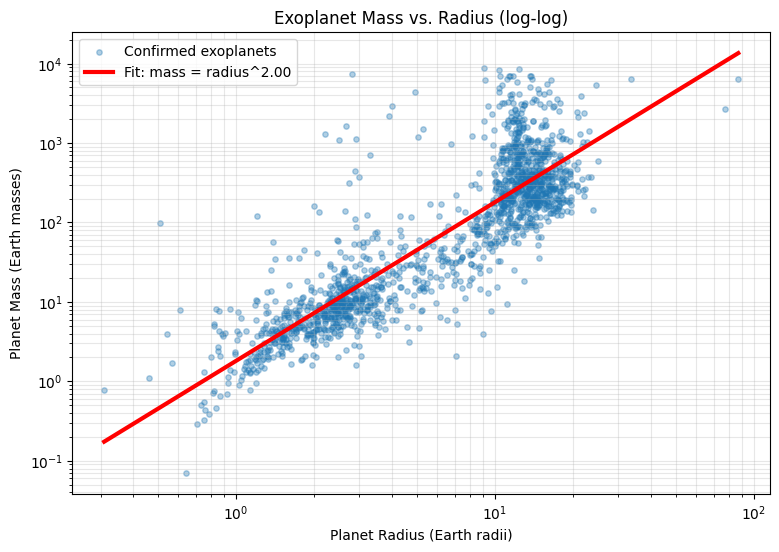

In [3]:
from sklearn.linear_model import LinearRegression

clean_df = exoplanets_df.dropna(subset=["radius_earth_radii", "mass_earth_masses"])
clean_df = clean_df[(clean_df["radius_earth_radii"] > 0) & (clean_df["mass_earth_masses"] > 0)]

log_radius = np.log10(clean_df["radius_earth_radii"].values).reshape(-1, 1)
log_mass = np.log10(clean_df["mass_earth_masses"].values)

model = LinearRegression()
model.fit(log_radius, log_mass)

power_law_exponent = model.coef_[0]
power_law_intercept = model.intercept_

print(f"Fitted relationship: mass = 10^{power_law_intercept:.2f} * radius^{power_law_exponent:.2f}")
print(f"({len(clean_df):,} planets used)")

radius_line = np.linspace(log_radius.min(), log_radius.max(), 200).reshape(-1, 1)
mass_line = model.predict(radius_line)

plt.figure(figsize=(9, 6))
plt.scatter(clean_df["radius_earth_radii"], clean_df["mass_earth_masses"], alpha=0.35, s=15, label="Confirmed exoplanets")
plt.plot(10**radius_line, 10**mass_line, color="red", linewidth=3,
         label=f"Fit: mass = radius^{power_law_exponent:.2f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Planet Radius (Earth radii)")
plt.ylabel("Planet Mass (Earth masses)")
plt.title("Exoplanet Mass vs. Radius (log-log)")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()

# Unsupervised Learning: Planet Type Clustering

K-Means on log(radius) and log(orbital period) tends to separate rough planet categories — e.g. short-period "hot" planets vs. long-period giants — without being told any labels.

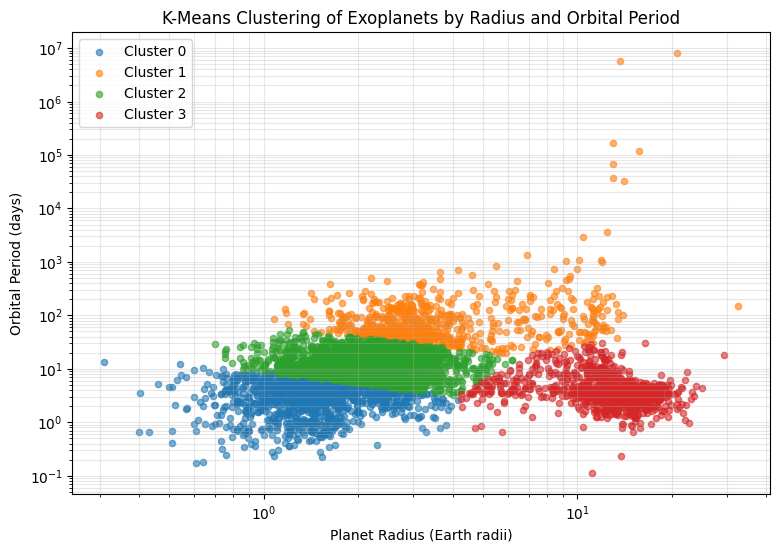

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_df = exoplanets_df.dropna(subset=["radius_earth_radii", "orbital_period_days"])
cluster_df = cluster_df[(cluster_df["radius_earth_radii"] > 0) & (cluster_df["orbital_period_days"] > 0)]

X = np.column_stack([
    np.log10(cluster_df["radius_earth_radii"].values),
    np.log10(cluster_df["orbital_period_days"].values)
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

colors = plt.cm.tab10(np.arange(n_clusters))

plt.figure(figsize=(9, 6))
for cluster_id in range(n_clusters):
    mask = cluster_labels == cluster_id
    plt.scatter(
        cluster_df["radius_earth_radii"].values[mask],
        cluster_df["orbital_period_days"].values[mask],
        color=colors[cluster_id], alpha=0.6, s=20,
        label=f"Cluster {cluster_id}"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Planet Radius (Earth radii)")
plt.ylabel("Orbital Period (days)")
plt.title("K-Means Clustering of Exoplanets by Radius and Orbital Period")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()